In [1]:
import pandas as pd

easy_df = pd.read_csv('data/chem_map_easy_master_v4.csv')
hard_df = pd.read_csv('data/chem_map_hard_master_v4.csv')

In [2]:
attr_column_str = "sequence_length,gc_content,sequence_entropy,average_longest_gc_helix,mfe,ens_def,longest_consecutive_A,longest_consecutive_C,longest_consecutive_G,longest_consecutive_U,avg_gu_pairs,averge_bps_predicted,hairpin_count,helix_count,single_strand_count,junction_count,average_mway_count,longest_singlestrand,average_singlestrand_size,longest_helix,average_helix_size,average_hamming_distance_of_preds,average_au_pairs_of_helices,helices_with_reverse_compliment,rate_of_gt_4_unpaired_nt_in_hairpin"
attr_columns = attr_column_str.split(",")
attr_columns

['sequence_length',
 'gc_content',
 'sequence_entropy',
 'average_longest_gc_helix',
 'mfe',
 'ens_def',
 'longest_consecutive_A',
 'longest_consecutive_C',
 'longest_consecutive_G',
 'longest_consecutive_U',
 'avg_gu_pairs',
 'averge_bps_predicted',
 'hairpin_count',
 'helix_count',
 'single_strand_count',
 'junction_count',
 'average_mway_count',
 'longest_singlestrand',
 'average_singlestrand_size',
 'longest_helix',
 'average_helix_size',
 'average_hamming_distance_of_preds',
 'average_au_pairs_of_helices',
 'helices_with_reverse_compliment',
 'rate_of_gt_4_unpaired_nt_in_hairpin']

In [3]:
from data_utils import pretty_attr_map

pretty_attr_map

{'sequence_length': 'Sequence Length',
 'gc_content': 'GC-Content',
 'sequence_entropy': 'Sequence Entropy',
 'average_longest_gc_helix': 'Longest GC Helix',
 'mfe': 'MFE',
 'ens_def': 'Ensemble Defect',
 'longest_consecutive_A': 'Longest Conesecutive A',
 'longest_consecutive_C': 'Longest Conesecutive C',
 'longest_consecutive_G': 'Longest Conesecutive G',
 'longest_consecutive_U': 'Longest Conesecutive U',
 'avg_gu_pairs': 'GU Pairs',
 'averge_bps_predicted': 'Average Basepairs Predicted',
 'hairpin_count': 'Average Hairpin Count',
 'helix_count': 'Average Helix Count',
 'single_strand_count': 'Average Single Strand Count',
 'junction_count': 'Average Junction Count',
 'average_mway_count': 'Average Multiway Junction Count',
 'longest_singlestrand': 'Longest Single Strand',
 'average_singlestrand_size': 'Average Single Strand Size',
 'longest_helix': 'Longest Helix',
 'average_helix_size': 'Average Helix Size',
 'average_hamming_distance_of_preds': 'Average Hamming Distance Between P

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


attrs_to_plot_with_log = [
    "ens_def",
]

attrs_to_plot_with_bar_plot = [
    "sequence_length",
    "longest_consecutive_A",
    "longest_consecutive_C",
    "longest_consecutive_G",
    "longest_consecutive_U",
    "longest_singlestrand",
    "longest_helix",
]


def plot_hard_easy_kde_with_log(key):
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = "Arial"

    if key not in easy_df.columns or key not in hard_df.columns:
        raise KeyError(f"Key '{key}' not found in easy_df or hard_df")

    easy_vals = easy_df[key].dropna()
    hard_vals = hard_df[key].dropna()
    use_log_scale = key in attrs_to_plot_with_log

    plt.figure(figsize=(8, 5))

    sns.kdeplot(
        data=hard_vals,
        color="#C51B7D",
        label="hard",
        fill=False
    )

    sns.kdeplot(
        data=easy_vals,
        color="#222222",
        label="easy",
        fill=False
    )

    plt.title(f"KDE of {pretty_attr_map.get(key, key)}")
    plt.xlabel(pretty_attr_map.get(key, key))
    plt.ylabel("Density")

    if use_log_scale:
        plt.xscale("log")

    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_hard_easy_stacked_bar(key, bin_width=None, max_bins=30):
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = "Arial"

    if key not in easy_df.columns or key not in hard_df.columns:
        raise KeyError(f"Key '{key}' not found in easy_df or hard_df")

    easy_vals = easy_df[key].dropna()
    hard_vals = hard_df[key].dropna()

    all_vals = pd.concat([easy_vals, hard_vals])

    if all_vals.empty:
        raise ValueError(f"No values found for key '{key}'")

    min_val = all_vals.min()
    max_val = all_vals.max()

    # Choose a reasonable bin width automatically if not provided
    if bin_width is None:
        value_range = max_val - min_val

        if value_range <= max_bins:
            bin_width = 1
        else:
            bin_width = int(np.ceil(value_range / max_bins))

    # Build bins
    bin_start = np.floor(min_val)
    bin_end = np.ceil(max_val) + bin_width

    bins = np.arange(bin_start, bin_end + bin_width, bin_width)

    easy_counts, bin_edges = np.histogram(easy_vals, bins=bins)
    hard_counts, _ = np.histogram(hard_vals, bins=bins)

    # Make readable bin labels
    bin_labels = []

    for left, right in zip(bin_edges[:-1], bin_edges[1:]):
        if bin_width == 1:
            bin_labels.append(str(int(left)))
        else:
            bin_labels.append(f"{int(left)}-{int(right - 1)}")

    x = np.arange(len(bin_labels))

    plt.figure(figsize=(10, 5))

    plt.bar(
        x,
        hard_counts,
        color="#C51B7D",
        label="hard",
        edgecolor="black",
        linewidth=0.4
    )

    plt.bar(
        x,
        easy_counts,
        bottom=hard_counts,
        color="#222222",
        label="easy",
        edgecolor="black",
        linewidth=0.4
    )

    plt.title(f"Easy vs. Hard Distribution of {pretty_attr_map.get(key, key)}")
    plt.xlabel(pretty_attr_map.get(key, key))
    plt.ylabel("Count")

    plt.xticks(
        x,
        bin_labels,
        rotation=45,
        ha="right",
        fontsize=8
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_hard_easy_attr(key):
    if key in attrs_to_plot_with_bar_plot:
        plot_hard_easy_stacked_bar(key)
    else:
        plot_hard_easy_kde_with_log(key)

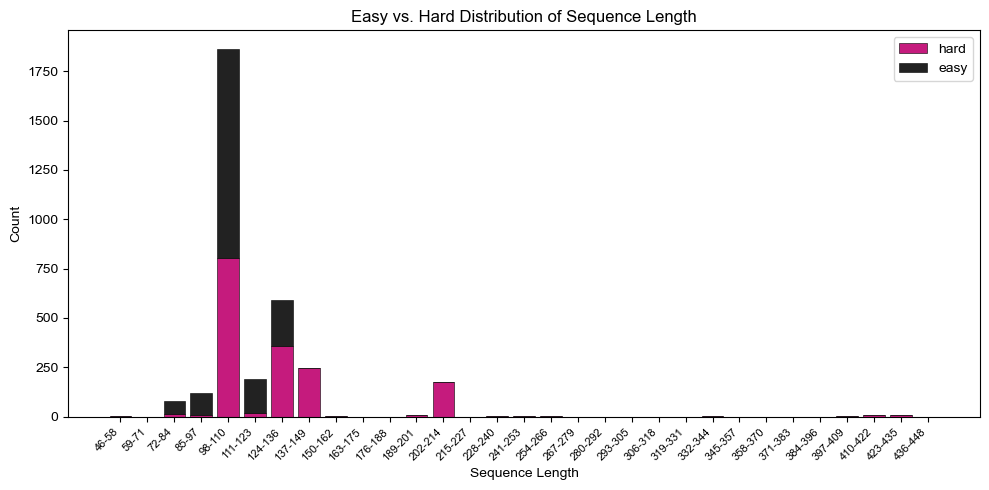

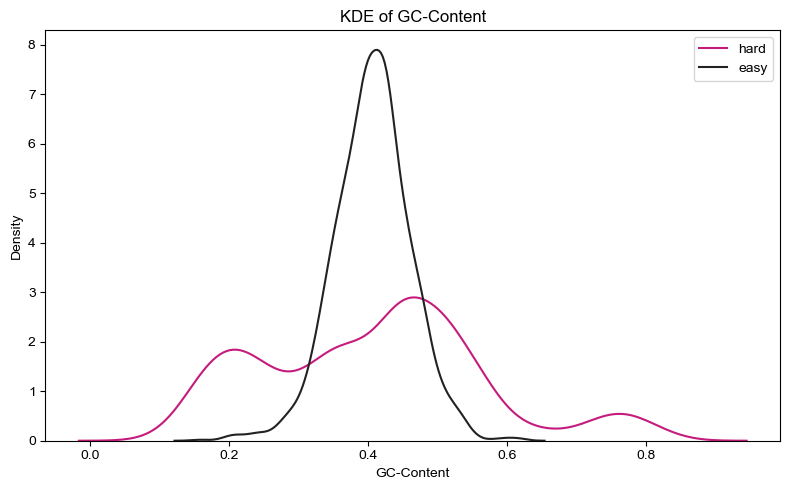

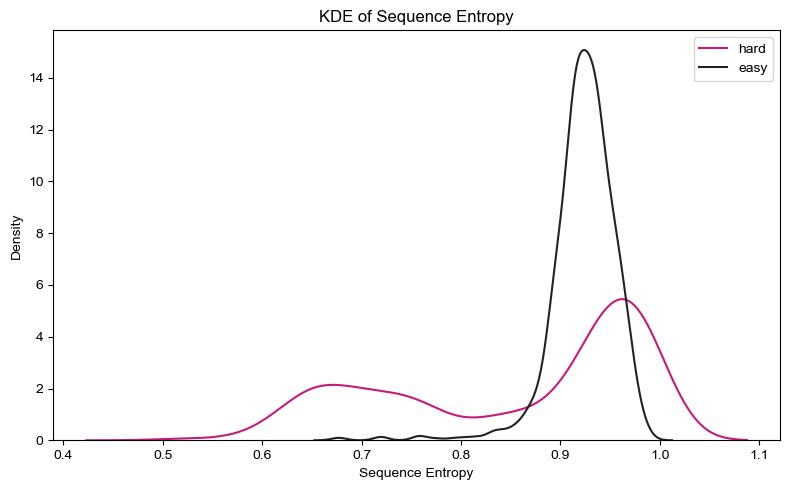

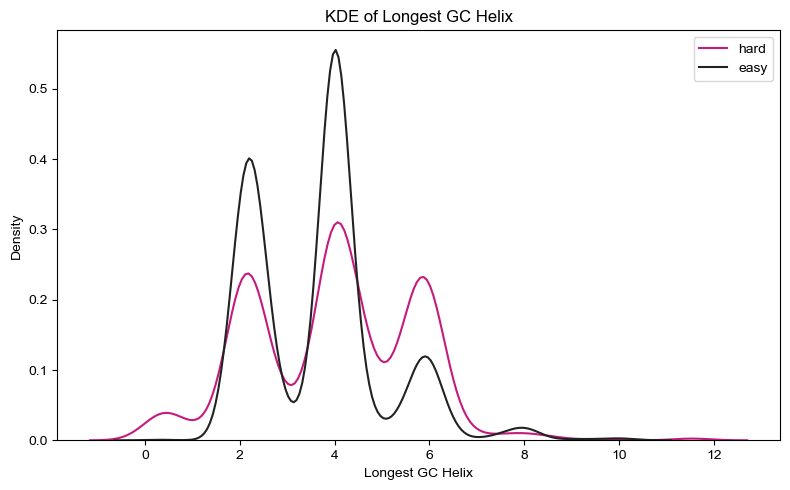

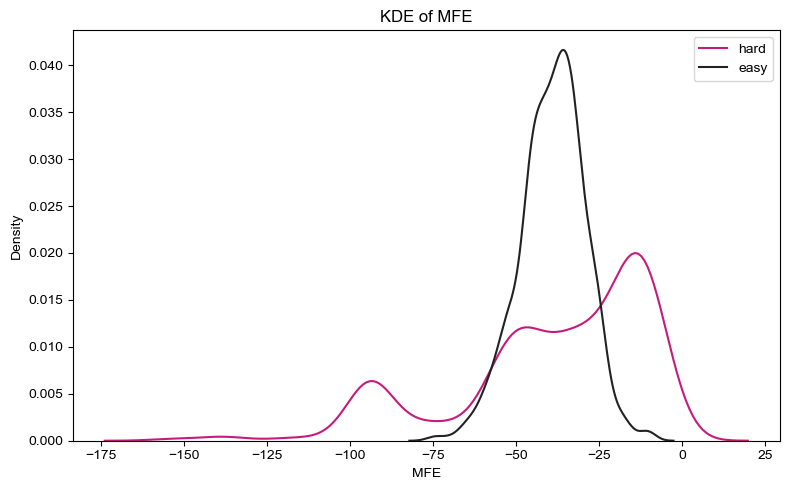

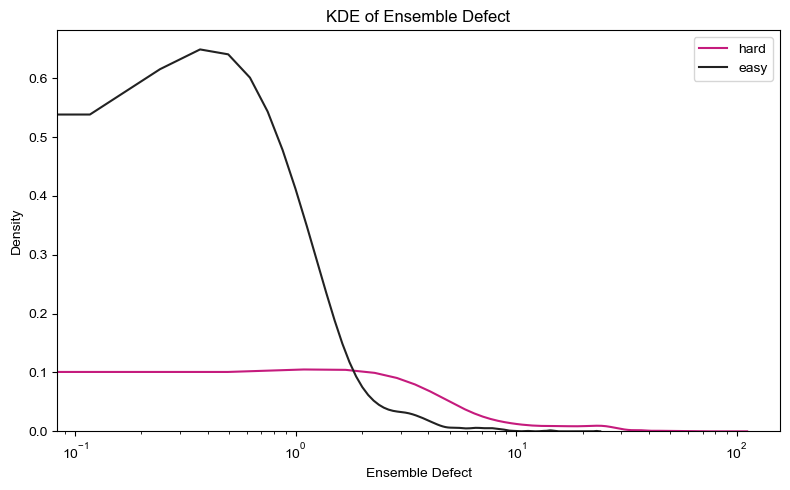

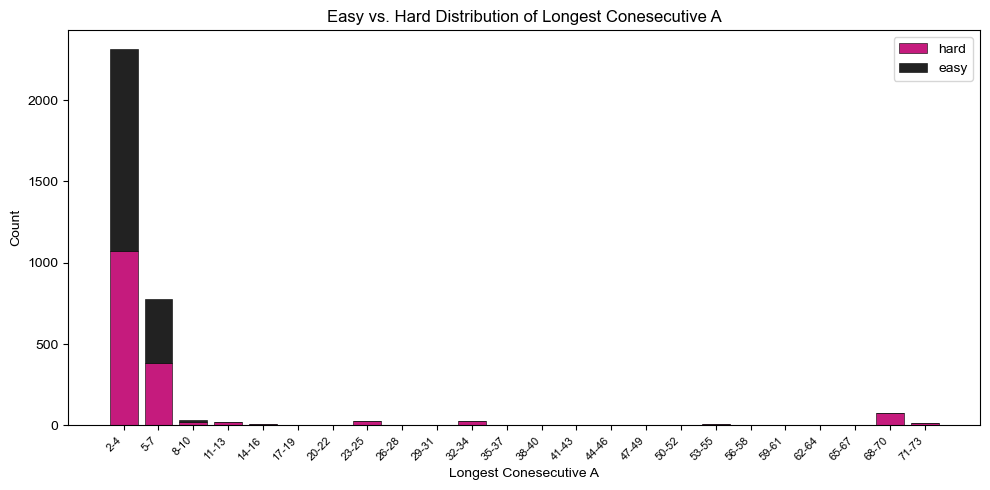

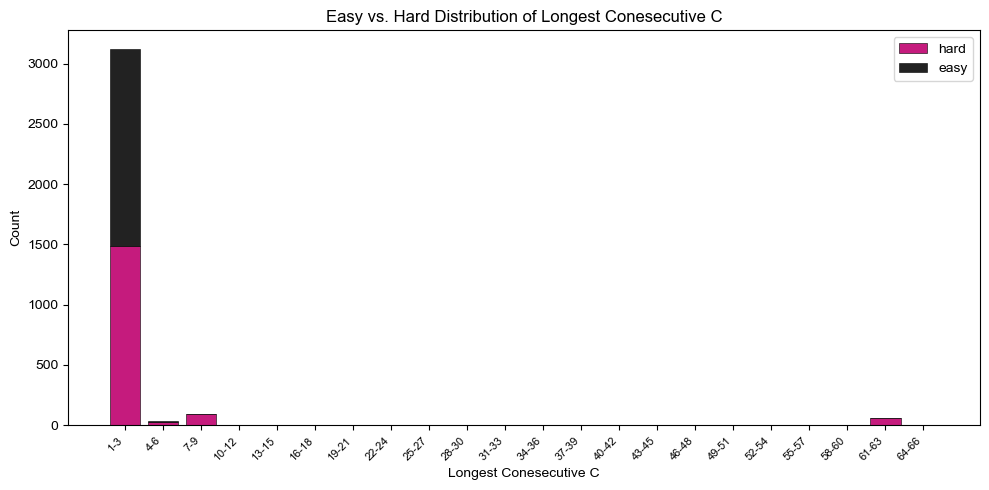

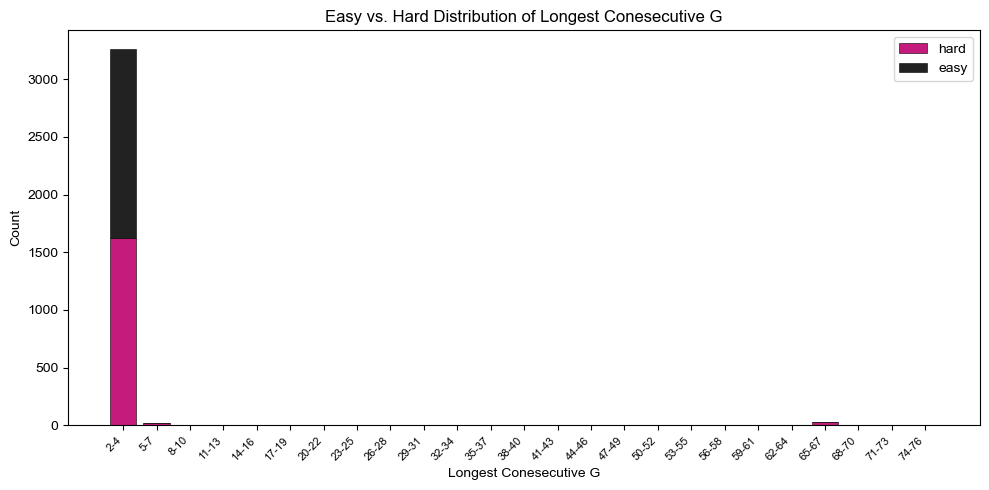

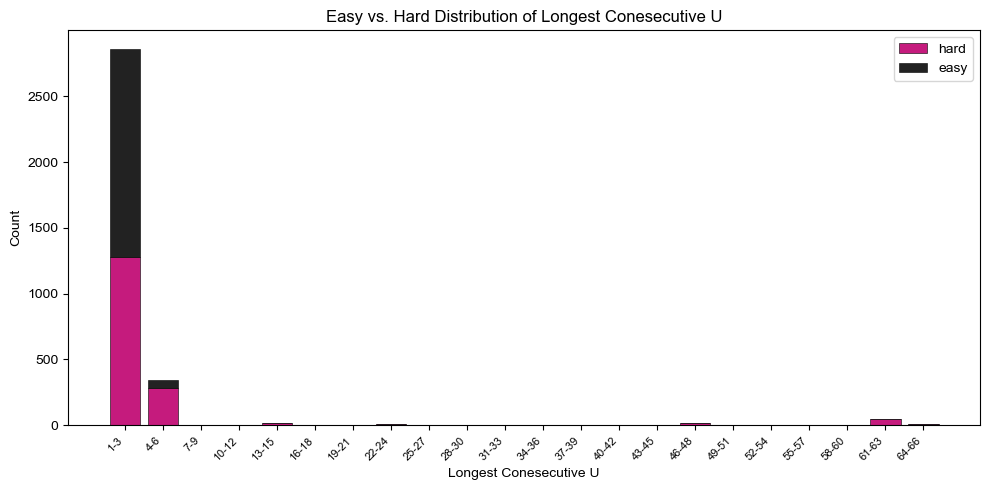

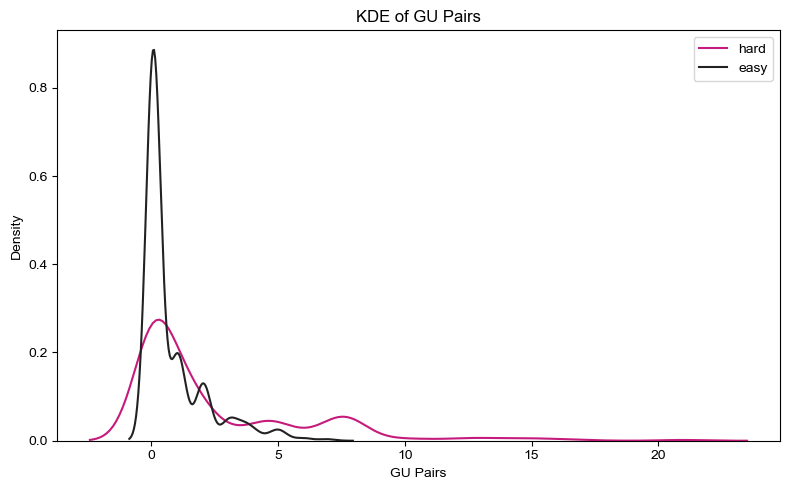

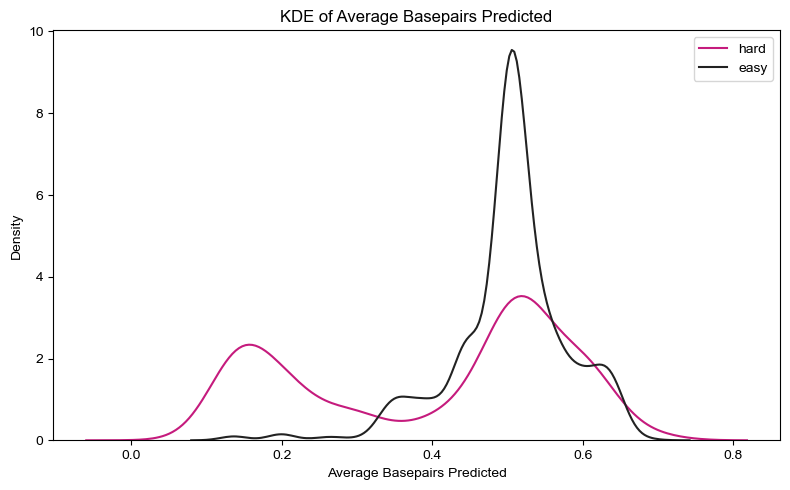

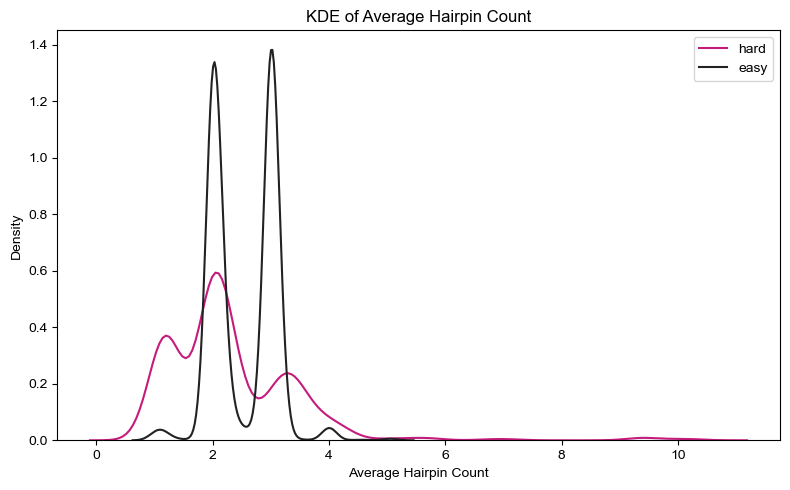

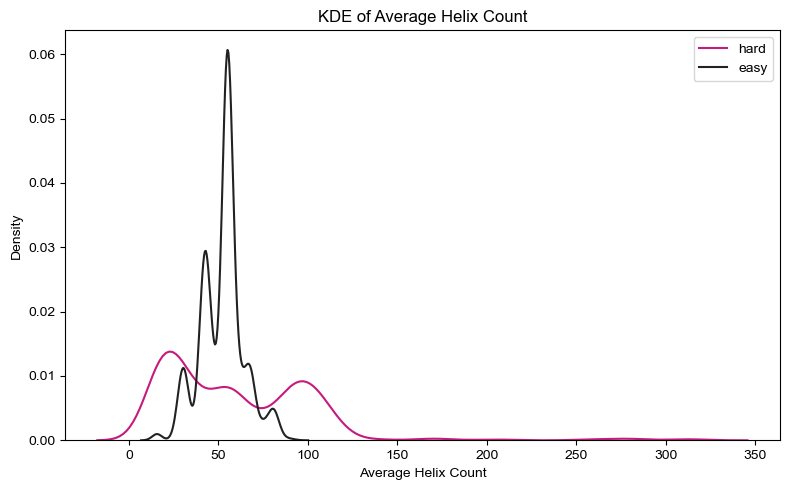

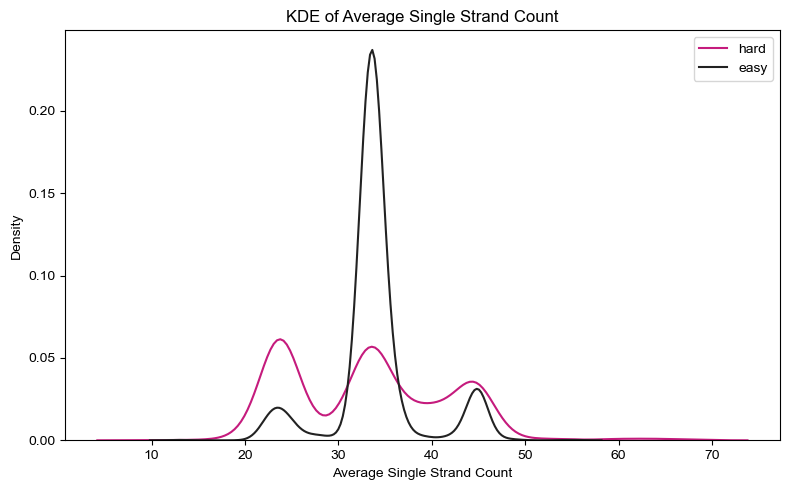

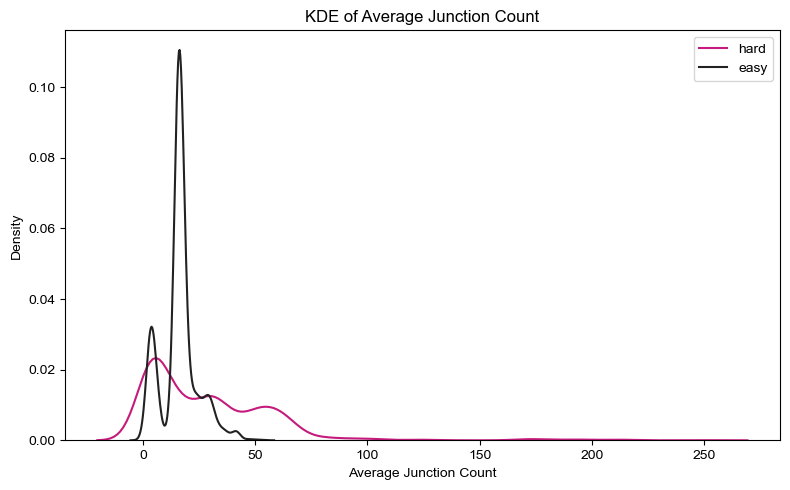

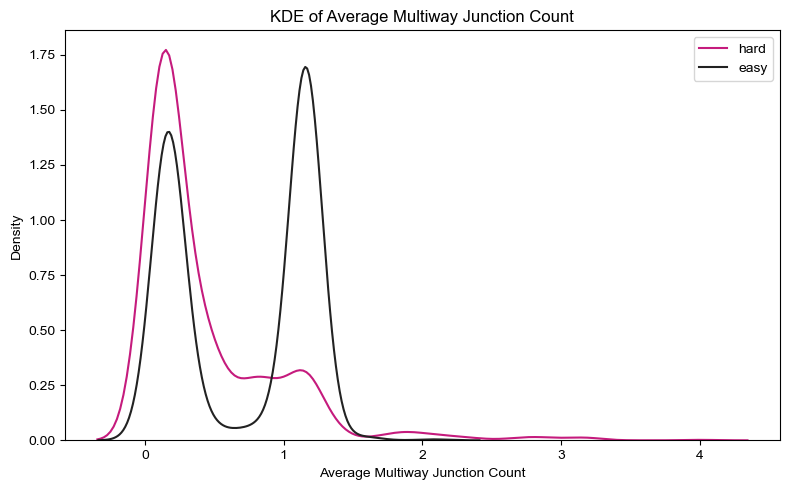

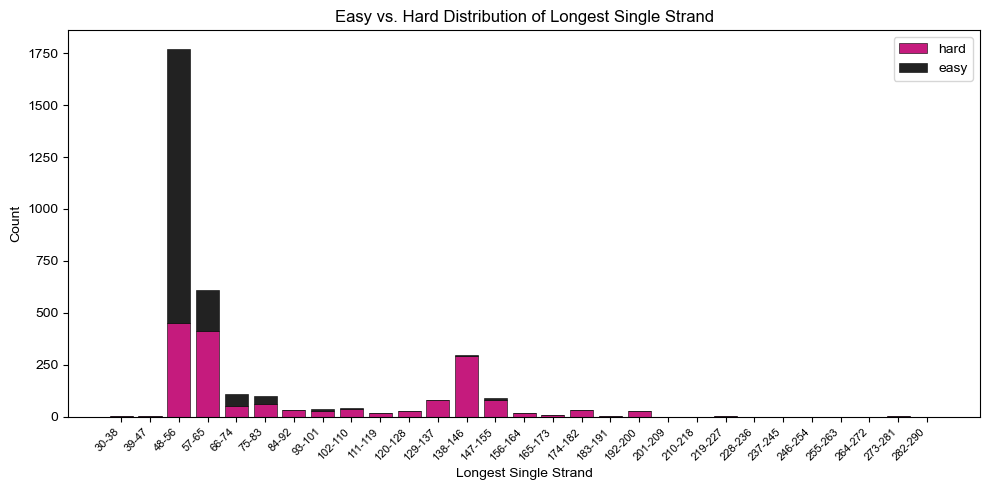

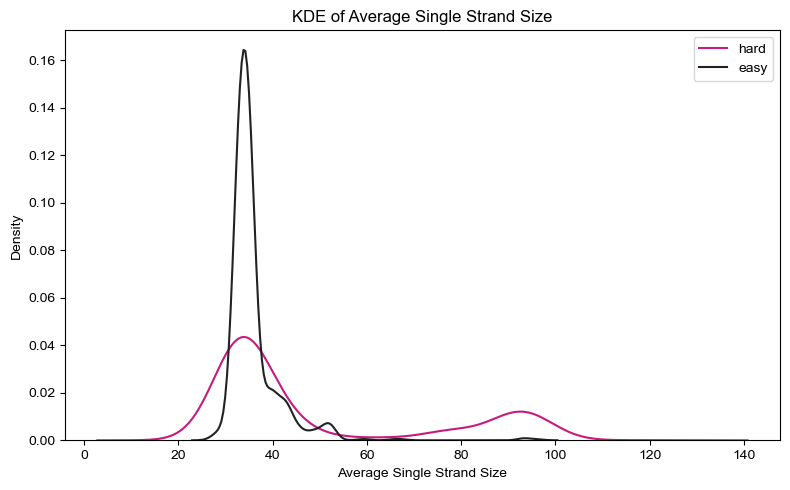

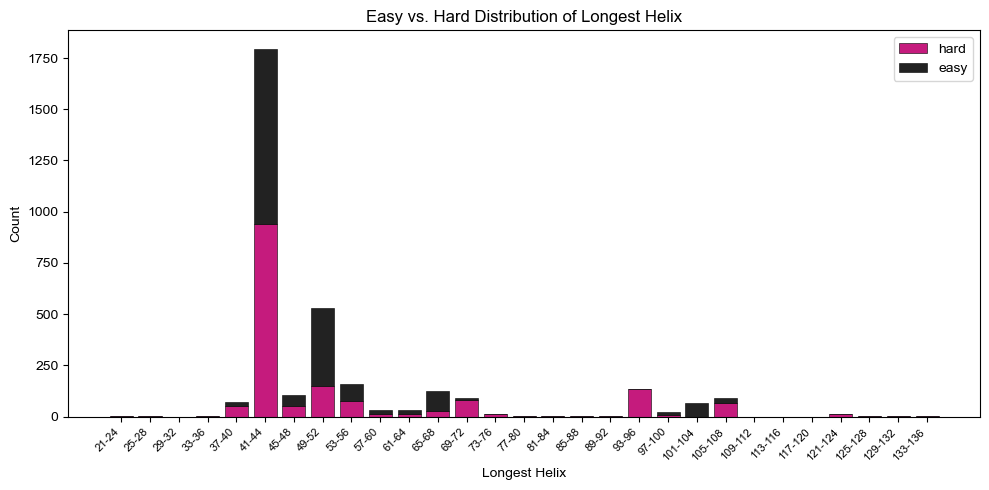

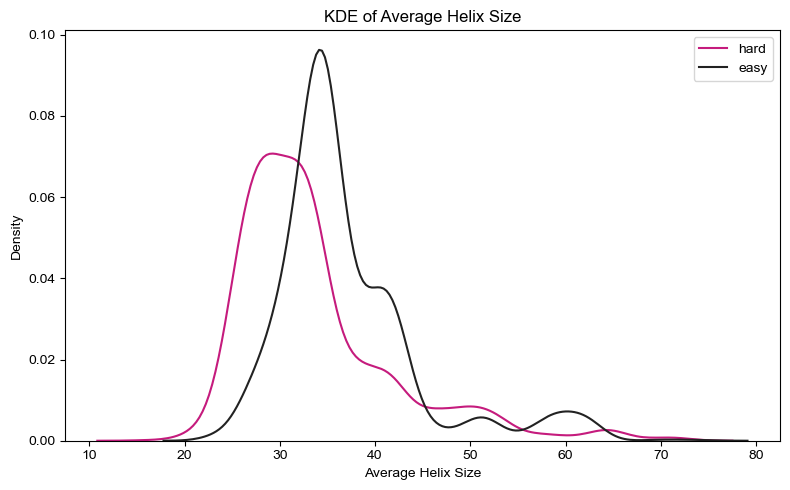

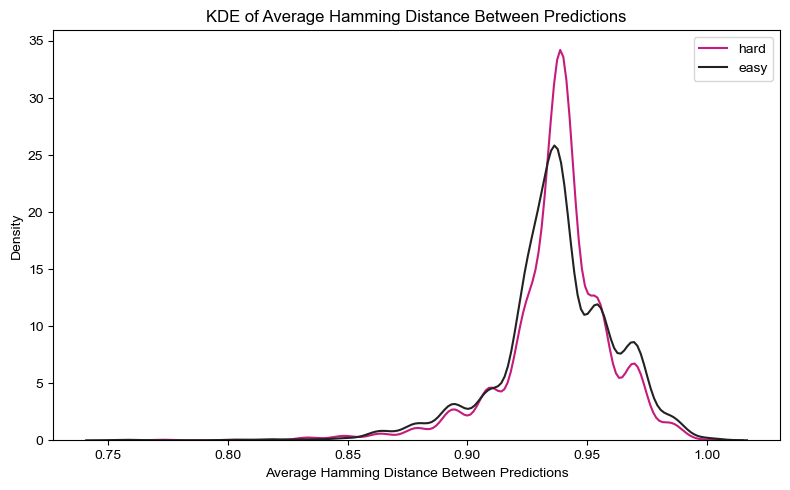

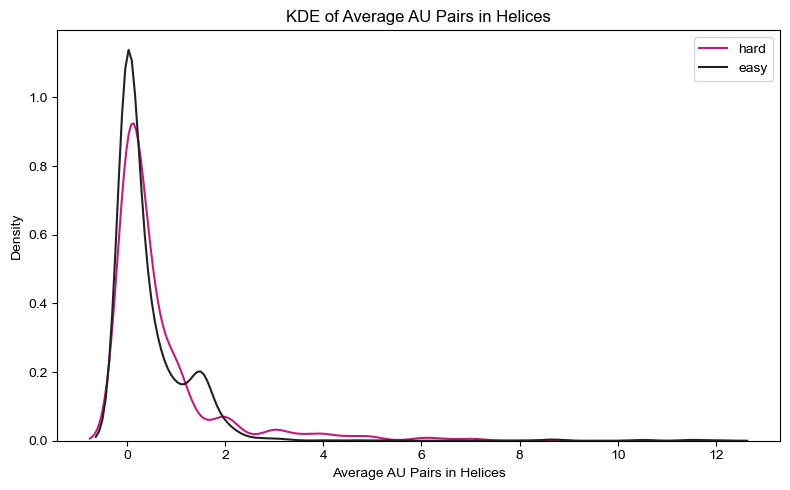

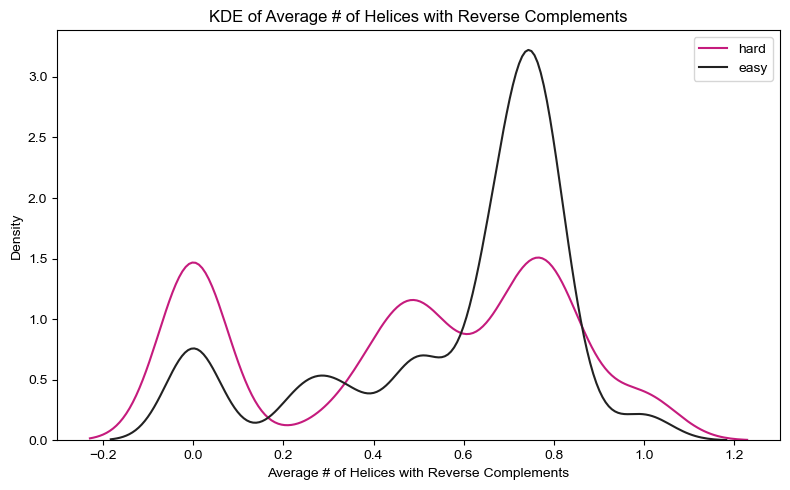

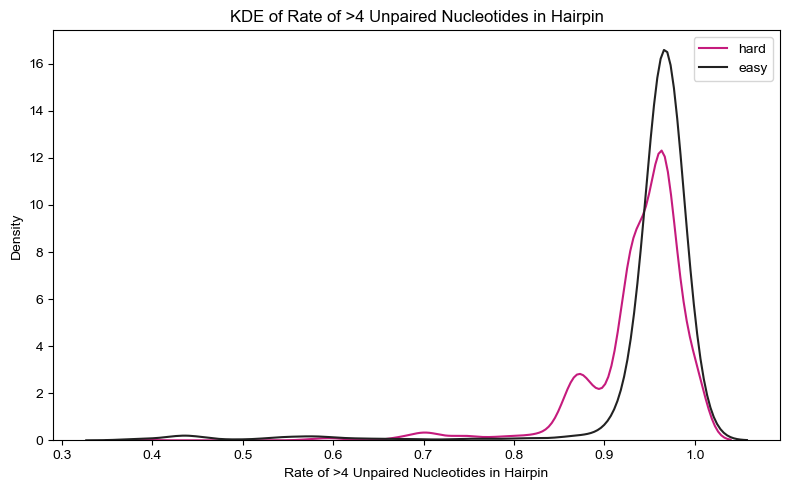

In [12]:
for k in pretty_attr_map:
    plot_hard_easy_attr(k)

In [13]:
len(pretty_attr_map)

25

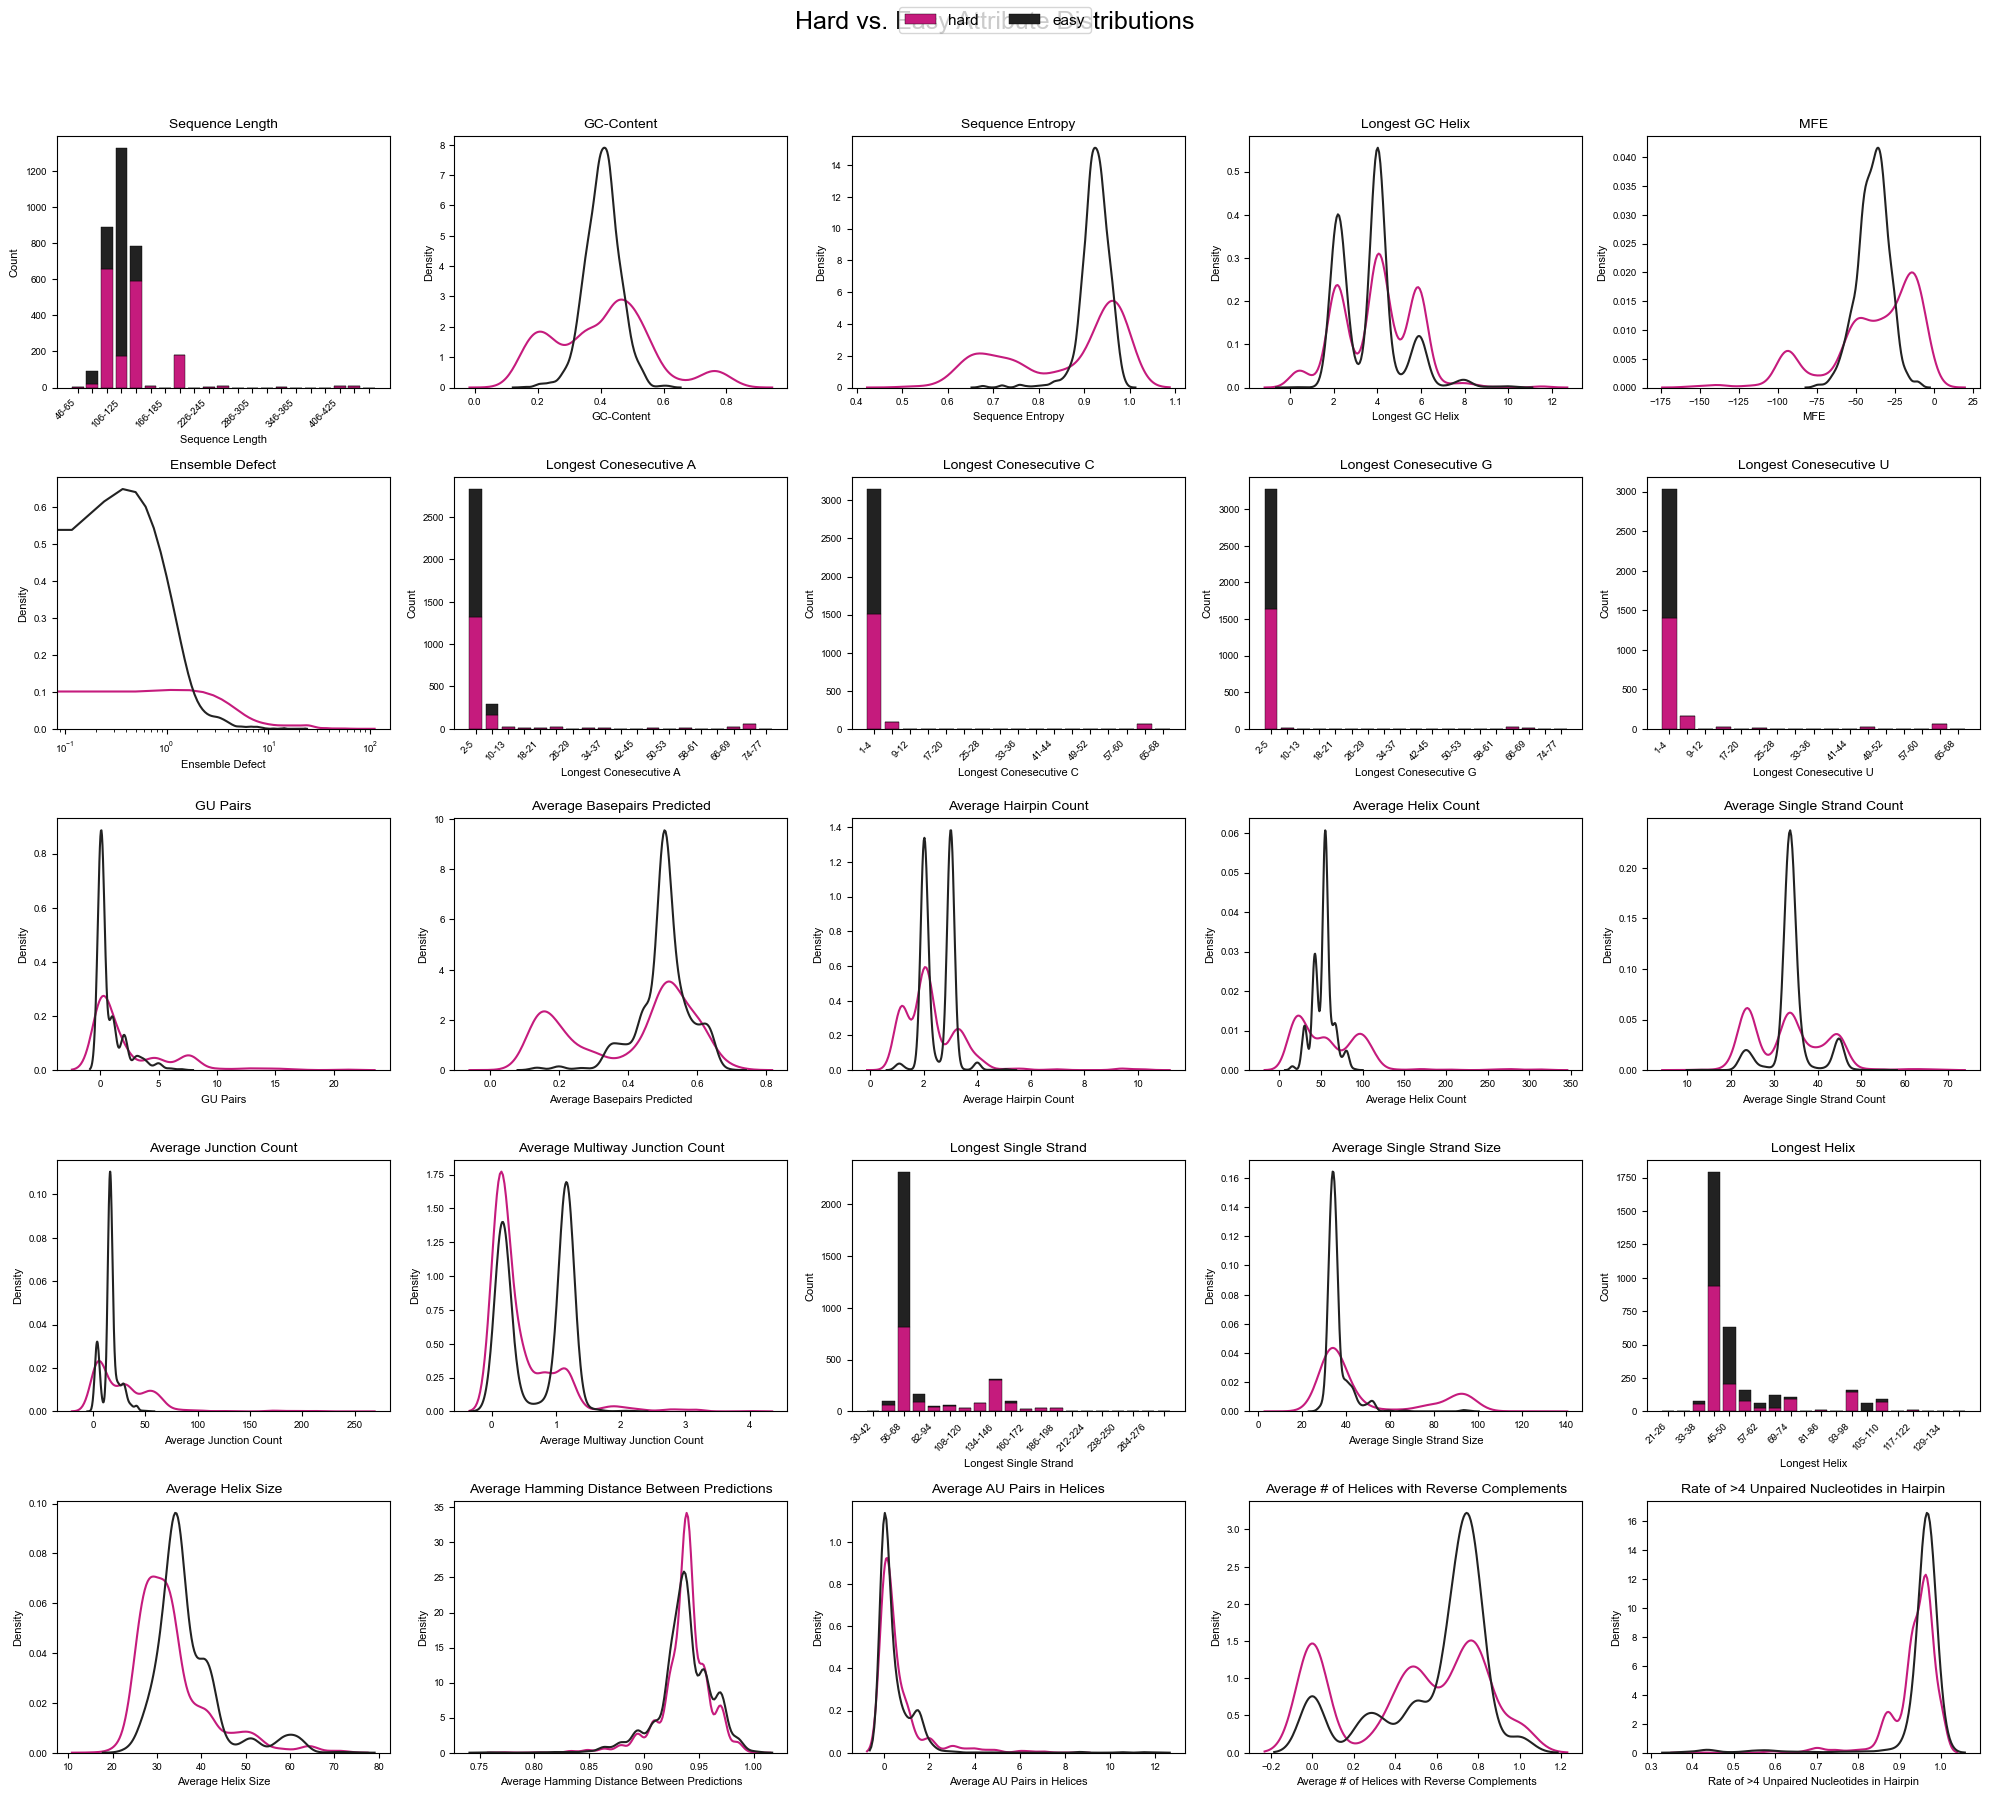

In [17]:
def plot_hard_easy_kde_on_ax(key, ax):
    if key not in easy_df.columns or key not in hard_df.columns:
        raise KeyError(f"Key '{key}' not found in easy_df or hard_df")

    easy_vals = easy_df[key].dropna()
    hard_vals = hard_df[key].dropna()
    use_log_scale = key in attrs_to_plot_with_log

    sns.kdeplot(
        data=hard_vals,
        color="#C51B7D",
        label="hard",
        fill=False,
        ax=ax
    )

    sns.kdeplot(
        data=easy_vals,
        color="#222222",
        label="easy",
        fill=False,
        ax=ax
    )

    ax.set_title(pretty_attr_map.get(key, key), fontsize=10)
    ax.set_xlabel(pretty_attr_map.get(key, key), fontsize=8)
    ax.set_ylabel("Density", fontsize=8)

    if use_log_scale:
        ax.set_xscale("log")

    ax.tick_params(axis="both", labelsize=7)


def plot_hard_easy_stacked_bar_on_ax(key, ax, bin_width=None, max_bins=20):
    if key not in easy_df.columns or key not in hard_df.columns:
        raise KeyError(f"Key '{key}' not found in easy_df or hard_df")

    easy_vals = easy_df[key].dropna()
    hard_vals = hard_df[key].dropna()

    all_vals = pd.concat([easy_vals, hard_vals])

    if all_vals.empty:
        raise ValueError(f"No values found for key '{key}'")

    min_val = all_vals.min()
    max_val = all_vals.max()

    # Choose a reasonable bin width automatically if not provided
    if bin_width is None:
        value_range = max_val - min_val

        if value_range <= max_bins:
            bin_width = 1
        else:
            bin_width = int(np.ceil(value_range / max_bins))

    bin_start = np.floor(min_val)
    bin_end = np.ceil(max_val) + bin_width

    bins = np.arange(bin_start, bin_end + bin_width, bin_width)

    easy_counts, bin_edges = np.histogram(easy_vals, bins=bins)
    hard_counts, _ = np.histogram(hard_vals, bins=bins)

    bin_labels = []

    for left, right in zip(bin_edges[:-1], bin_edges[1:]):
        if bin_width == 1:
            bin_labels.append(str(int(left)))
        else:
            bin_labels.append(f"{int(left)}-{int(right - 1)}")

    x = np.arange(len(bin_labels))

    ax.bar(
        x,
        hard_counts,
        color="#C51B7D",
        label="hard",
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        x,
        easy_counts,
        bottom=hard_counts,
        color="#222222",
        label="easy",
        edgecolor="black",
        linewidth=0.3
    )

    ax.set_title(pretty_attr_map.get(key, key), fontsize=10)
    ax.set_xlabel(pretty_attr_map.get(key, key), fontsize=8)
    ax.set_ylabel("Count", fontsize=8)

    ax.set_xticks(x)

    # Avoid overcrowding x-axis labels
    if len(bin_labels) > 10:
        step = int(np.ceil(len(bin_labels) / 10))
        shown_labels = [
            label if i % step == 0 else ""
            for i, label in enumerate(bin_labels)
        ]
        ax.set_xticklabels(shown_labels, rotation=45, ha="right", fontsize=7)
    else:
        ax.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=7)

    ax.tick_params(axis="y", labelsize=7)


def plot_hard_easy_attr_on_ax(key, ax):
    if key in attrs_to_plot_with_bar_plot:
        plot_hard_easy_stacked_bar_on_ax(key, ax)
    else:
        plot_hard_easy_kde_on_ax(key, ax)


# ------------------------------------------------------------
# Create 5 x 5 grid
# ------------------------------------------------------------

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = "Arial"

n_rows = 5
n_cols = 5

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 18),
    squeeze=False
)

axes_flat = axes.flatten()

for ax, key in zip(axes_flat, pretty_attr_map):
    plot_hard_easy_attr_on_ax(key, ax)

# Hide unused axes
for ax in axes_flat[len(pretty_attr_map):]:
    ax.set_visible(False)

# One shared legend for the whole figure
handles, labels = axes_flat[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    fontsize=11
)

fig.suptitle(
    "Hard vs. Easy Attribute Distributions",
    fontsize=18,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.965])

plt.savefig(
    "hard_vs_easy_grid.png",
    dpi=500,
    bbox_inches="tight"
)

plt.show()